# MDP Homework

## Group Members

| No. | Name                       | Student Number |
| :-: | -------------------------- | :------------: |
|  1  | **Lulama Unity Hlungwani** |   **3127972**  |
|  2  | **Okwukwechukwu Mbajiorgu**|   **2430639**  |
|  3  | **Adivhaho Nevondo**       |   **2580619**  |
|  4  | Member 4             |  |

---

# Table of Contents

# Table of Contents

1. **Introduction**
2. **MDP Formulation**
3. **7×7 Gridworld Environment**
4. **Random Agent**
5. **Optimal Value Function**
6. **Greedy Agent**
7. **Results and Comparison**
8. **Sample Trajectories**
9. **Conclusion**



## 1. Introduction to Markov Decision Processes

According to the MDP slides, an MDP provides a framework for sequential decision-making in reinforcement learning.
An MDP is represented by the tuple $(S,A,P,R,\gamma)$.
In this homework, these concepts are applied to a deterministic 7×7 Gridworld.


## 2. MDP Formulation

The state is the cell currently occupied by the agent, and the available actions are up, down, left, and right.
The transition dynamics determine the next state after an action.
The agent receives rewards according to the specified reward function, with no discounting $(\gamma=1)$.


## 3. 7×7 Gridworld Environment

The environment consists of a 7×7 grid with obstacles in the third row, except for the right-most cell.
The agent starts at the bottom-left cell and the goal is at the top-left cell.
The `GridWorld` class implements the states, actions, transitions, rewards, and terminal condition.


In [383]:

class GridWorld:

    def __init__(self):
        self.rows = 7
        self.cols = 7

        self.start_state = (6, 0)
        self.goal_state = (0, 0)

        self.obstacles = {
            (2, 0), (2, 1), (2, 2),
            (2, 3), (2, 4), (2, 5)
        }

        self.actions = {
            'up': (-1, 0),
            'down': (1, 0),
            'left': (0, -1),
            'right': (0, 1)
        }

        self.state = self.start_state

    def reset(self):
        self.state = self.start_state
        return self.state

    def is_valid_state(self, state):
        row, col = state

        return (
            0 <= row < self.rows
            and 0 <= col < self.cols
            and state not in self.obstacles
        )

    def step(self, action):

        if action not in self.actions:
            raise ValueError(f"Invalid action: {action}")

        row_change, col_change = self.actions[action]

        new_state = (
            self.state[0] + row_change,
            self.state[1] + col_change
        )

        is_valid = self.is_valid_state(new_state)

        if is_valid:
            self.state = new_state
        else:
            new_state = self.state
            # Agent stays in the same state if movement is invalid

        # Reward
        reward = 20 if new_state == self.goal_state else -1

        # Episode termination
        done = new_state == self.goal_state

        return new_state, reward, done

    def print_grid(self):
        #Print the current state of the GridWorld.

        for row in range(self.rows):

            row_display = ""

            for col in range(self.cols):

                state = (row, col)

                if state == self.state:
                    cell = " A "

                elif state == self.goal_state:
                    cell = " G "

                elif state == self.start_state:
                    cell = " S "

                elif state in self.obstacles:
                    cell = " X "

                else:
                    cell = " . "

                row_display += cell

            print(row_display)


In [384]:
# Create the GridWorld environment
env = GridWorld()

# Display the initial state
print("Initial state:", env.state)
print()

env.print_grid()

Initial state: (6, 0)

 G  .  .  .  .  .  . 
 .  .  .  .  .  .  . 
 X  X  X  X  X  X  . 
 .  .  .  .  .  .  . 
 .  .  .  .  .  .  . 
 .  .  .  .  .  .  . 
 A  .  .  .  .  .  . 


**Random Agent**

In [385]:
import numpy as np

def randomAgent(env, max_steps=50):

    state = env.reset()
    tot_reward = 0
    trajectory = [state]

    for step_ in range(1, max_steps + 1):

        # Randomly select one of the available actions
        action = np.random.choice(list(env.actions.keys()))

        next_state, reward, done = env.step(action)

        tot_reward += reward
        trajectory.append(next_state)

        state = next_state

        if done:
            return step_, tot_reward, True, trajectory

    return max_steps, tot_reward, False, trajectory

Run the Random Agent for 20 Episodes

In [386]:
env = GridWorld()

episodes_num = 20
results = []

sample_trajectory = None

for i in range(episodes_num):

    steps, total_reward, goal_reached, trajectory = randomAgent(
        env,
        max_steps=50
    )

    results.append({
        "steps": steps,
        "total_reward": total_reward,
        "goal_reached": goal_reached
    })

    # Store the first episode as the sample trajectory
    if i == 0:
        sample_trajectory = trajectory

print(results)

[{'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': False}, {'steps': 50, 'total_reward': -50, 'goal_reached': Fals

In [387]:
average_random_return = np.mean(
    [result["total_reward"] for result in results]
)

print("Average random agent return:", average_random_return)

Average random agent return: -50.0


## Optimal Value Function

The MDP slides define the value of a state as the expected return obtained from that state under a policy.
The optimal value is the maximum value that can be obtained:

$$
v^*(s)=\max_{\pi}v_{\pi}(s)
$$

For this Gridworld, the optimal values are calculated by considering the shortest path to the goal.


In [388]:
# Optimal value function calculated by hand

# v* derivation,- v*(s) = 21 - d(s), where d(s) = min moves to goal
# (v*(goal) = 0 as a special case; goal is a terminal state)

# --- Region 1: rows 0-1 (above the obstacle row, no obstruction) ---
# d(r,c) = r + c   -- direct distance, nothing blocks the path
#
# (0,0)=goal -> v*=0
# (0,1): d=0+1=1 -> v*=21-1=20
# (0,2): d=0+2=2 -> v*=19
# (0,3): d=0+3=3 -> v*=18
# (0,4): d=0+4=4 -> v*=17
# (0,5): d=0+5=5 -> v*=16
# (0,6): d=0+6=6 -> v*=15
# (1,0): d=1+0=1 -> v*=20
# (1,1): d=1+1=2 -> v*=19
# (1,2): d=1+2=3 -> v*=18
# (1,3): d=1+3=4 -> v*=17
# (1,4): d=1+4=5 -> v*=16
# (1,5): d=1+5=6 -> v*=15
# (1,6): d=1+6=7 -> v*=14

# --- Region 2: row 2, the only open cell is (2,6) ---
# (2,6): d=2+6=8 -> v*=21-8=13

# --- Region 3: rows 3-6 (below the obstacle row, forced through (2,6)) ---
# d(r,c) = r + |c-6| + 6   -- r moves up, plus a detour to col 6 and back to col 0
#
# row 3: (3,0) d=3+6+6=15 v*=6 | (3,1) d=14 v*=7 | (3,2) d=13 v*=8
#        (3,3) d=12 v*=9 | (3,4) d=11 v*=10 | (3,5) d=10 v*=11 | (3,6) d=9 v*=12
#
# row 4: (4,0) d=16 v*=5 | (4,1) d=15 v*=6 | (4,2) d=14 v*=7
#        (4,3) d=13 v*=8 | (4,4) d=12 v*=9 | (4,5) d=11 v*=10 | (4,6) d=10 v*=11
#
# row 5: (5,0) d=17 v*=4 | (5,1) d=16 v*=5 | (5,2) d=15 v*=6
#        (5,3) d=14 v*=7 | (5,4) d=13 v*=8 | (5,5) d=12 v*=9 | (5,6) d=11 v*=10
#
# row 6: (6,0)=START d=18 v*=3 | (6,1) d=17 v*=4 | (6,2) d=16 v*=5
#        (6,3) d=15 v*=6 | (6,4) d=14 v*=7 | (6,5) d=13 v*=8 | (6,6) d=12 v*=9


v_star = {
    (0, 0): 0,
    (0, 1): 20, (0, 2): 19, (0, 3): 18, (0, 4): 17, (0, 5): 16, (0, 6): 15,
    (1, 0): 20, (1, 1): 19, (1, 2): 18, (1, 3): 17, (1, 4): 16, (1, 5): 15, (1, 6): 14,
    (2, 6): 13,
    (3, 0): 6, (3, 1): 7, (3, 2): 8, (3, 3): 9, (3, 4): 10, (3, 5): 11, (3, 6): 12,
    (4, 0): 5, (4, 1): 6, (4, 2): 7, (4, 3): 8, (4, 4): 9, (4, 5): 10, (4, 6): 11,
    (5, 0): 4, (5, 1): 5, (5, 2): 6, (5, 3): 7, (5, 4): 8, (5, 5): 9, (5, 6): 10,
    (6, 0): 3, (6, 1): 4, (6, 2): 5, (6, 3): 6, (6, 4): 7, (6, 5): 8, (6, 6): 9,
}


In [389]:
print("Optimal Value Function:")

for row in range(7):
    row_values = []

    for col in range(7):
        state = (row, col)

        if state in env.obstacles:
            row_values.append(" X ")
        else:
            row_values.append(f"{v_star[state]:2}")

    print("  ".join(row_values))

Optimal Value Function:
 0  20  19  18  17  16  15
20  19  18  17  16  15  14
 X    X    X    X    X    X   13
 6   7   8   9  10  11  12
 5   6   7   8   9  10  11
 4   5   6   7   8   9  10
 3   4   5   6   7   8   9


In [390]:
def predict_next_state(env, state, action):
    row_change, col_change = env.actions[action] # we are trying to predict the next state

    candidate = (
        state[0] + row_change,
        state[1] + col_change
    )

    if env.is_valid_state(candidate):
        next_state = candidate
    else:
        next_state = state

    reward = 20 if next_state == env.goal_state else -1

    return next_state, reward



The reward function for a state-action pair is defined as:

$$
r(s,a)=\mathbb{E}[R_t\mid S_{t-1}=s,A_{t-1}=a]
$$

For state-action-next-state triples, the expected reward is:

$$
r(s,a,s')=\mathbb{E}[R_t\mid S_{t-1}=s,A_{t-1}=a,S_t=s']
$$

Since our Gridworld is deterministic, the reward is directly determined by the state and action.
The greedy agent then uses the one-step lookahead value:

$$
r(s,a)+v^*(s')
$$

and selects the action with the highest value.


In [391]:
def select_greedy_action(env, state, v_star):

    best_action = None
    best_value = float('-inf')

    for action in env.actions:

        next_state, reward = predict_next_state(
            env, state, action
        )

        value = reward + v_star[next_state]

        if value > best_value:
            best_value = value
            best_action = action

    return best_action

In [392]:
def greedyAgent(env, v_star, max_steps=50):

    state = env.reset()
    tot_reward = 0
    trajectory = [state]

    for step_ in range(1, max_steps + 1):

        action = select_greedy_action(
            env, state, v_star
        )

        next_state, reward, done = env.step(action)

        tot_reward += reward
        trajectory.append(next_state)

        state = next_state

        if done:
            return step_, tot_reward, True, trajectory

    return max_steps, tot_reward, False, trajectory

**The greedy experiment**

In [393]:
env = GridWorld()

episodes_num = 20
greedy_results = []

greedy_sample_trajectory = None

for i in range(episodes_num):

    steps, total_reward, goal_reached, trajectory = greedyAgent(
        env,
        v_star,
        max_steps=50
    )

    greedy_results.append({
        "steps": steps,
        "total_reward": total_reward,
        "goal_reached": goal_reached
    })

    if i == 0:
        greedy_sample_trajectory = trajectory

print(greedy_results)

[{'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached': True}, {'steps': 18, 'total_reward': 3, 'goal_reached'

In [394]:
average_greedy_return = np.mean(
    [result["total_reward"] for result in greedy_results]
)

print("Average greedy agent return:", average_greedy_return)

Average greedy agent return: 3.0


**Comparison of average  returns**

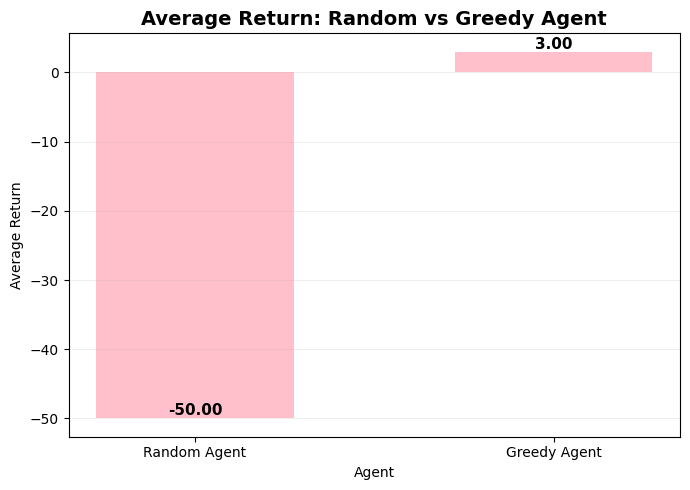

In [395]:
import matplotlib.pyplot as plt
import numpy as np

agents = ["Random Agent", "Greedy Agent"]
average_returns = [
    average_random_return,
    average_greedy_return
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    agents,
    average_returns,
    width=0.55,
    color="pink"
)

plt.title(
    "Average Return: Random vs Greedy Agent",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Average Return")
plt.xlabel("Agent")
plt.grid(axis="y", alpha=0.2)

# Add the values above the bars

for bar, value in zip(bars, average_returns):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**Sample Trajectories**

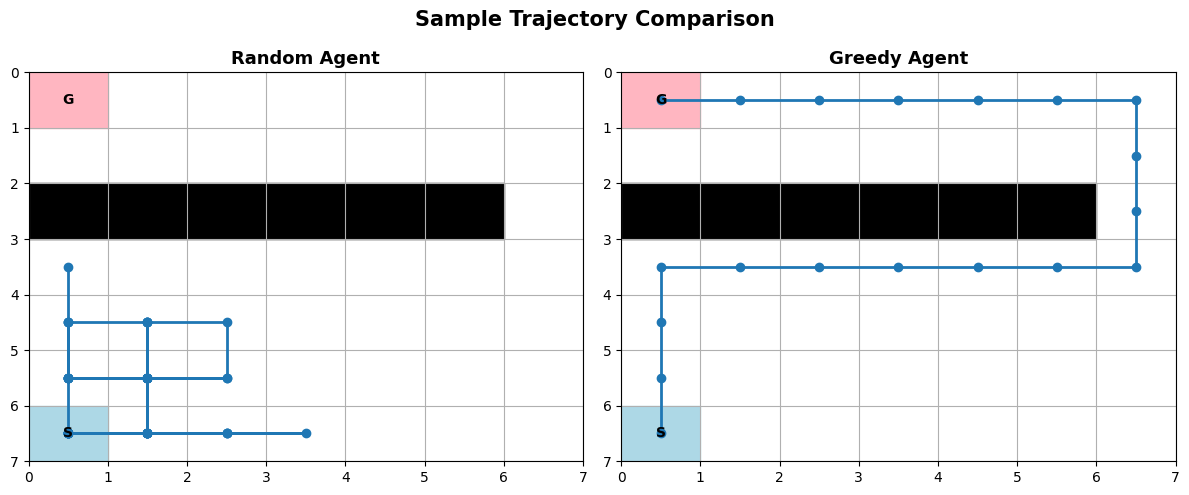

In [396]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


def draw_trajectory(ax, trajectory, title):

    # Draw grid
    ax.set_xlim(0, 7)
    ax.set_ylim(7, 0)

    ax.set_xticks(range(8))
    ax.set_yticks(range(8))

    ax.grid(True)

    # Draw obstacles
    for row, col in env.obstacles:
        ax.add_patch(
            plt.Rectangle(
                (col, row),
                1,
                1,
                color="black"
            )
        )

    # Draw goal
    goal_row, goal_col = env.goal_state

    ax.add_patch(
        plt.Rectangle(
            (goal_col, goal_row),
            1,
            1,
            color="lightpink"
        )
    )

    # Draw start
    start_row, start_col = env.start_state

    ax.add_patch(
        plt.Rectangle(
            (start_col, start_row),
            1,
            1,
            color="lightblue"
        )
    )

    # Plot trajectory
    rows = [state[0] + 0.5 for state in trajectory]
    cols = [state[1] + 0.5 for state in trajectory]

    ax.plot(
        cols,
        rows,
        marker="o",
        linewidth=2
    )

    # Labels
    ax.text(
        start_col + 0.5,
        start_row + 0.5,
        "S",
        ha="center",
        va="center",
        fontweight="bold"
    )

    ax.text(
        goal_col + 0.5,
        goal_row + 0.5,
        "G",
        ha="center",
        va="center",
        fontweight="bold"
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )


# Random agent
draw_trajectory(
    axes[0],
    sample_trajectory,
    "Random Agent"
)

# Greedy agent
draw_trajectory(
    axes[1],
    greedy_sample_trajectory,
    "Greedy Agent"
)

plt.suptitle(
    "Sample Trajectory Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()



The random agent selects actions without considering the value of the resulting states.
The greedy agent instead uses the optimal value function to select the action with the highest expected return.
Therefore, the greedy agent is expected to reach the goal more efficiently and achieve a higher average return.
The trajectory and return results provide a comparison of the behaviour and performance of the two agents.
